# Data Preparation

This notebook handles:
- Organizing Kaggle datasets
- Converting Roboflow COCO annotations to classification format
- Data validation and statistics

## Import Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Dataset Configuration

In [2]:
# Dataset paths
DATA_DIR = Path('../data')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'

# Expected classes
EXPECTED_CLASSES = {
    'Tomato': ['Tomato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 
               'Tomato___Bacterial_spot', 'Tomato___Leaf_Mold'],
    'Bell Pepper': ['Pepper,_bell___healthy', 'Pepper,_bell___Bacterial_spot'],
    'Chili': ['Chili___Healthy', 'Chili___Leaf_curl', 'Chili___Leaf_spot', 
              'Chili___Whitefly', 'Chili___Yellowish']
}

TOTAL_CLASSES = sum(len(classes) for classes in EXPECTED_CLASSES.values())
print(f"Expected classes: {TOTAL_CLASSES}")
print(f"Dataset location: {DATA_DIR.absolute()}")

Expected classes: 12
Dataset location: c:\Users\evago\Documents\Plant-Disease-Detection\notebooks\..\data


## Verify Dataset Structure

In [3]:
# Check if directories exist
print("Directory Status:")
print(f"  Train directory: {'✓ Found' if TRAIN_DIR.exists() else '✗ Missing'}")
print(f"  Validation directory: {'✓ Found' if VAL_DIR.exists() else '✗ Missing'}")

# Get actual classes
if TRAIN_DIR.exists():
    train_classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
    print(f"\nActual classes found: {len(train_classes)}")
else:
    print("\n⚠ Warning: Train directory not found!")

Directory Status:
  Train directory: ✓ Found
  Validation directory: ✓ Found

Actual classes found: 12


## Dataset Statistics

In [4]:
def count_images(directory):
    """Count images in each class folder"""
    data = []
    image_extensions = {'.jpg', '.jpeg', '.png'}
    
    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            count = sum(1 for f in class_dir.iterdir() 
                       if f.suffix.lower() in image_extensions)
            data.append({'Class': class_dir.name, 'Count': count})
    
    return pd.DataFrame(data)

# Count images in train and validation sets
train_stats = count_images(TRAIN_DIR)
val_stats = count_images(VAL_DIR)

# Display statistics
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"\nTrain Images: {train_stats['Count'].sum():,}")
print(f"Validation Images: {val_stats['Count'].sum():,}")
print(f"Total Images: {train_stats['Count'].sum() + val_stats['Count'].sum():,}")
print(f"\nNumber of Classes: {len(train_stats)}")

DATASET STATISTICS

Train Images: 18,764
Validation Images: 3,917
Total Images: 22,681

Number of Classes: 12


In [5]:
# Detailed breakdown by plant type
print("\nTRAIN SET - Class Distribution:")
print("-" * 60)

for plant_type, classes in EXPECTED_CLASSES.items():
    print(f"\n{plant_type}:")
    plant_total = 0
    for class_name in classes:
        count = train_stats[train_stats['Class'] == class_name]['Count'].values
        if len(count) > 0:
            print(f"  {class_name}: {count[0]:,} images")
            plant_total += count[0]
    print(f"  Subtotal: {plant_total:,} images")


TRAIN SET - Class Distribution:
------------------------------------------------------------

Tomato:
  Tomato___healthy: 1,926 images
  Tomato___Early_blight: 1,920 images
  Tomato___Late_blight: 1,851 images
  Tomato___Bacterial_spot: 1,702 images
  Tomato___Leaf_Mold: 1,882 images
  Subtotal: 9,281 images

Bell Pepper:
  Pepper,_bell___healthy: 1,988 images
  Pepper,_bell___Bacterial_spot: 1,913 images
  Subtotal: 3,901 images

Chili:
  Chili___Healthy: 1,920 images
  Chili___Leaf_curl: 858 images
  Chili___Leaf_spot: 1,007 images
  Chili___Whitefly: 881 images
  Chili___Yellowish: 916 images
  Subtotal: 5,582 images


## Data Visualization

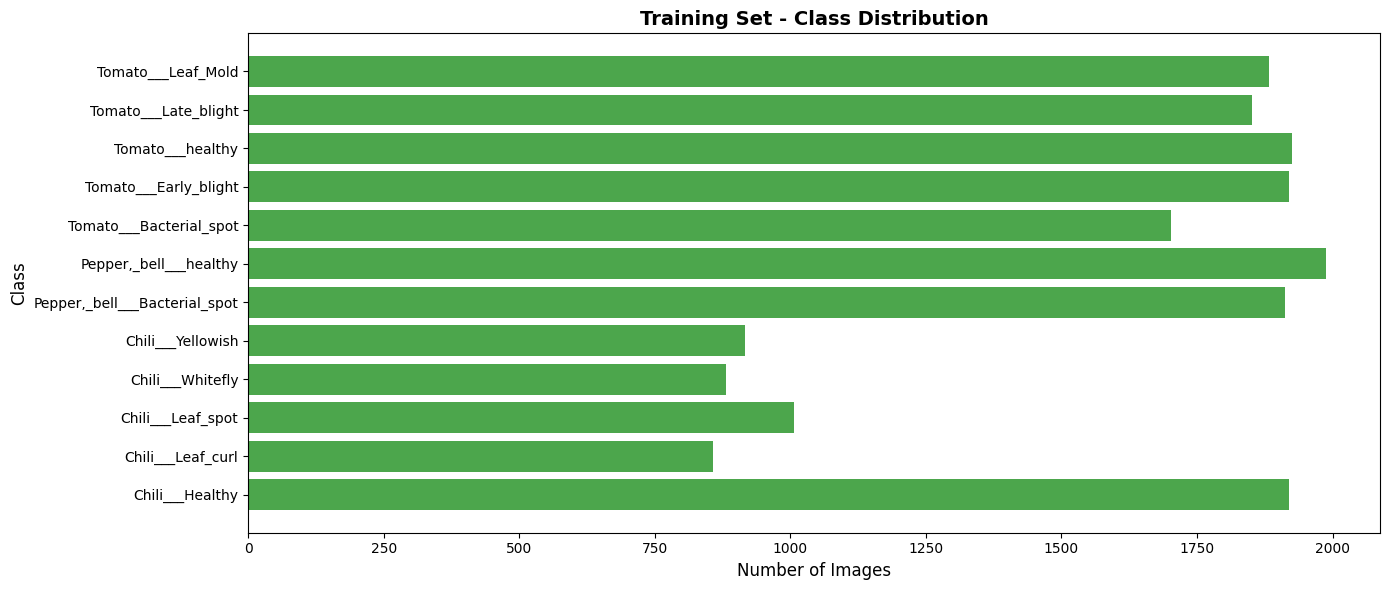

In [6]:
# Class distribution bar chart
plt.figure(figsize=(14, 6))
plt.barh(train_stats['Class'], train_stats['Count'], color='green', alpha=0.7)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

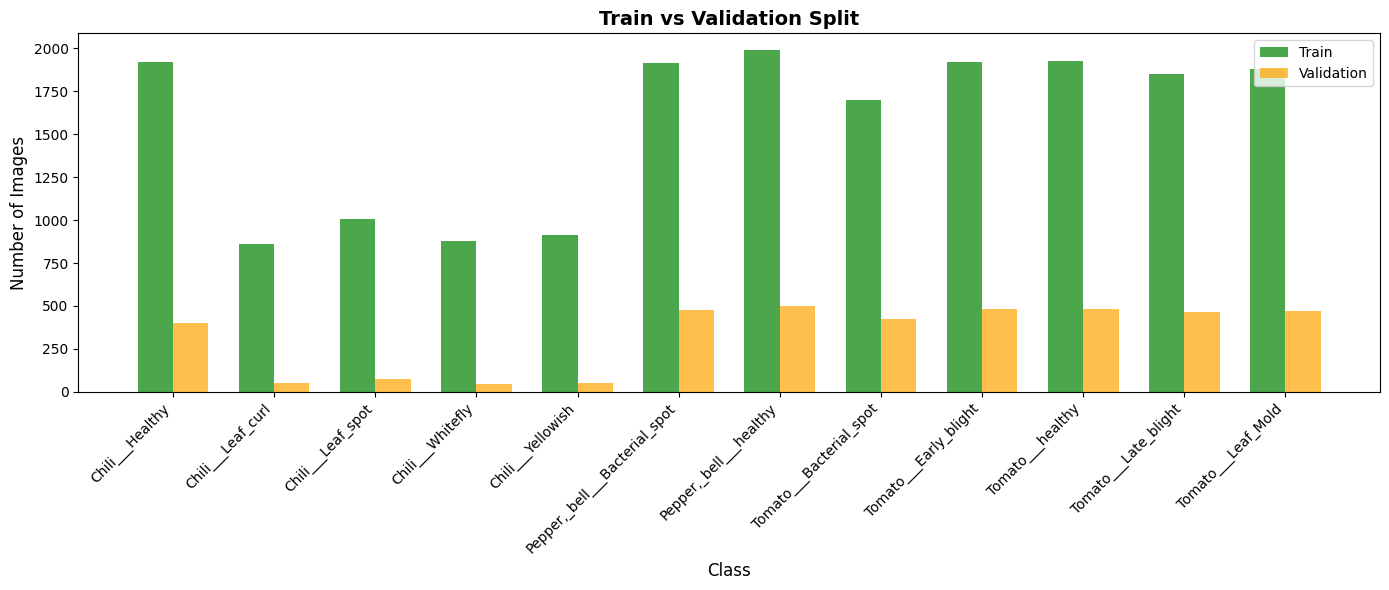

In [7]:
# Train vs Validation comparison
comparison_df = pd.merge(
    train_stats, val_stats, 
    on='Class', 
    suffixes=('_train', '_val')
)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(comparison_df))
width = 0.35

ax.bar([i - width/2 for i in x], comparison_df['Count_train'], 
       width, label='Train', color='green', alpha=0.7)
ax.bar([i + width/2 for i in x], comparison_df['Count_val'], 
       width, label='Validation', color='orange', alpha=0.7)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Train vs Validation Split', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Class'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()